# Projekt 3: Podstawy Gymnasium

**Autorzy**: Emilia Sarna, Kalina Rączka

**Data**: 23 kwietnia 2026r.

## Problem dyskretny: KungFu Master

**Środowisko:** `ALE/KungFuMaster-v5` (Atari 2600 - Arcade Learning Environment).

Agent steruje mistrzem kung-fu, który walczy z falami przeciwników. Za pokonanego wroga otrzymuje punkty, traci życie po trafieniach. Środowisko ma 14 dyskretnych akcji (kierunek + góra/nic/dół + cios/kop) i pasek życia. Naturalna nagroda to suma zdobytych punktów - cel: maksymalizacja.

Używamy obserwacji w postaci 128-bajtowego RAM-u Atari (dla Q-Learning) lub 4 ostatnich klatek 84×84 w skali szarości (dla DQN).

### Uczenie ze wzmocnieniem - algorytm

Uwzględniamy współczynnik dyskontowy równy 0.9

Zaimplementowaliśmy dwa algorytmy dla tego problemu:

**1. Q-Learning z dyskretyzacją stanu**
  - Klasyczny tabularny Q-Learning
  - Stan = wybrane 8 bajtów RAM-u (pozycja, życia, wrogowie) zbinowane na 4 koszyki
    - Pełen RAM (128 bajtów) daje przestrzeń stanów rzędu 8^128 - agent nigdy nie
      spotka tego samego stanu dwa razy
  - Polityka ε-greedy z malejącym ε (1.0 → 0.1, decay 0.995)
  - Hiperparametry: α=0.1, γ=0.9

**2. DQN (Deep Q-Network)**
  - Konwolucyjna sieć neuronowa (Conv→Conv→FC)
  - Wejście: 4 ostatnie klatki gry 84×84 w skali szarości
  - Replay buffer (10000) i polityka ε-greedy
  - Hiperparametry: γ=0.9, lr=2.5e-4, batch=32, target update=1000 kroków



In [11]:
import json, os
import pandas as pd

RESULTS = 'results'
with open(os.path.join(RESULTS, 'kungfu_qlearning', 'summary.json')) as f:
    s_q = json.load(f)
with open(os.path.join(RESULTS, 'kungfu_dqn', 'summary.json')) as f:
    s_dqn = json.load(f)

df = pd.DataFrame([
    {'Algorytm': s_q['algorithm'],   'Epizody': s_q['num_episodes'],
     'γ': s_q['gamma'], 'Najlepsza': s_q['best_reward'],
     'Średnia': round(s_q['mean_reward'],1), 'Pierwsze 25%': round(s_q['mean_first_25%'],1),
     'Ostatnie 25%': round(s_q['mean_last_25%'],1), 'Poprawa': round(s_q['improvement'],1)},
    {'Algorytm': s_dqn['algorithm'], 'Epizody': s_dqn['num_episodes'],
     'γ': s_dqn['gamma'], 'Najlepsza': s_dqn['best_reward'],
     'Średnia': round(s_dqn['mean_reward'],1), 'Pierwsze 25%': round(s_dqn['mean_first_25%'],1),
     'Ostatnie 25%': round(s_dqn['mean_last_25%'],1), 'Poprawa': round(s_dqn['improvement'],1)},
])
df

,Algorytm,Epizody,γ,Najlepsza,Średnia,Pierwsze 25%,Ostatnie 25%,Poprawa
0,Q-Learning,300,0.9,8000.0,1562.0,665.3,2946.7,2281.3
1,DQN,50,0.9,1400.0,598.0,500.0,669.2,169.2


### Krzywa uczenia

**Q-Learning (300 epizodów):** wyraźnie rosnąca średnia krocząca sumy nagród - od ok. 600 pkt na początku do ok. 2000 pkt pod koniec. Maksymalny wynik w pojedynczym epizodzie: 8000 pkt. Agent eksploruje 239 unikatowych stanów (z teoretycznie ~65k), co tłumaczy dlaczego wyniki się stabilizują - bardzo niewielka część przestrzeni stanów jest opanowana.

**DQN (50 epizodów):** krótszy trening (każdy epizod to ok. 10 sekund obliczeń, vs ok. 0.3 s dla Q-Learning), ale i da się zauwazyć poprawę wyników. 

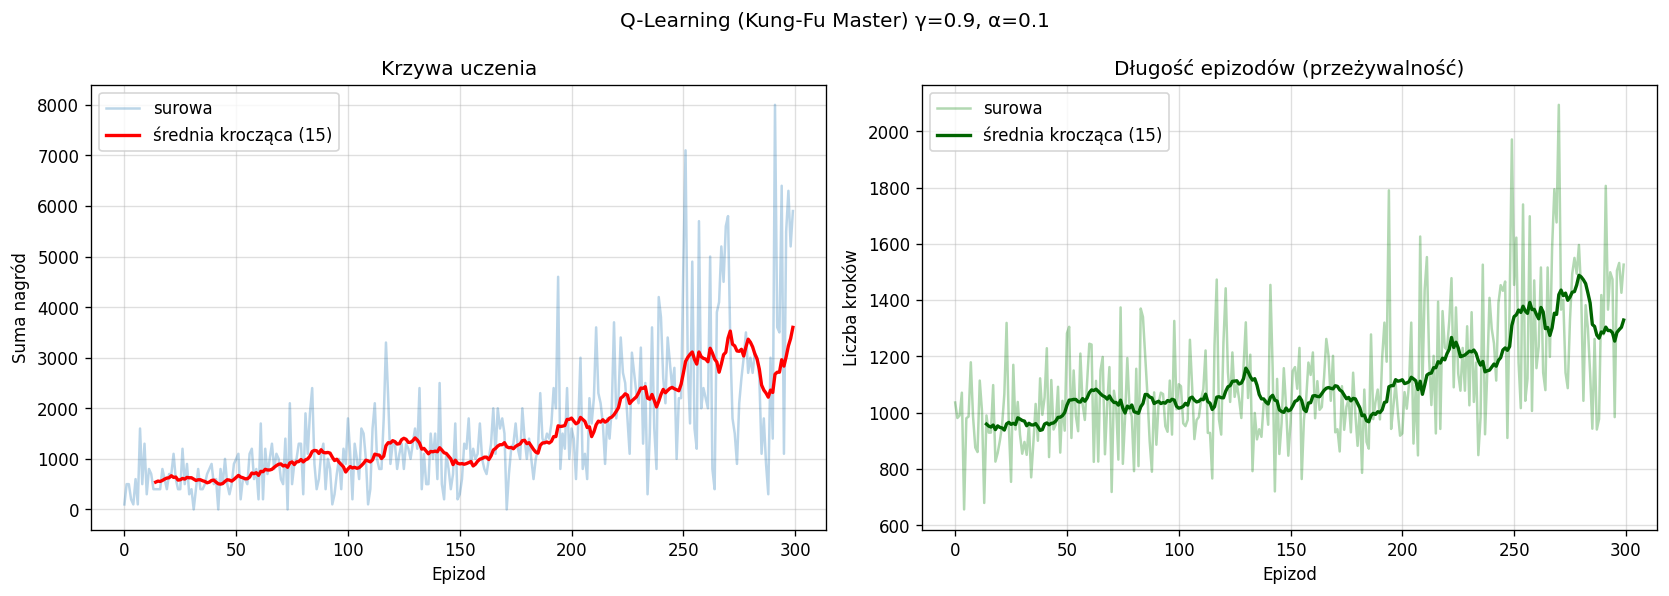

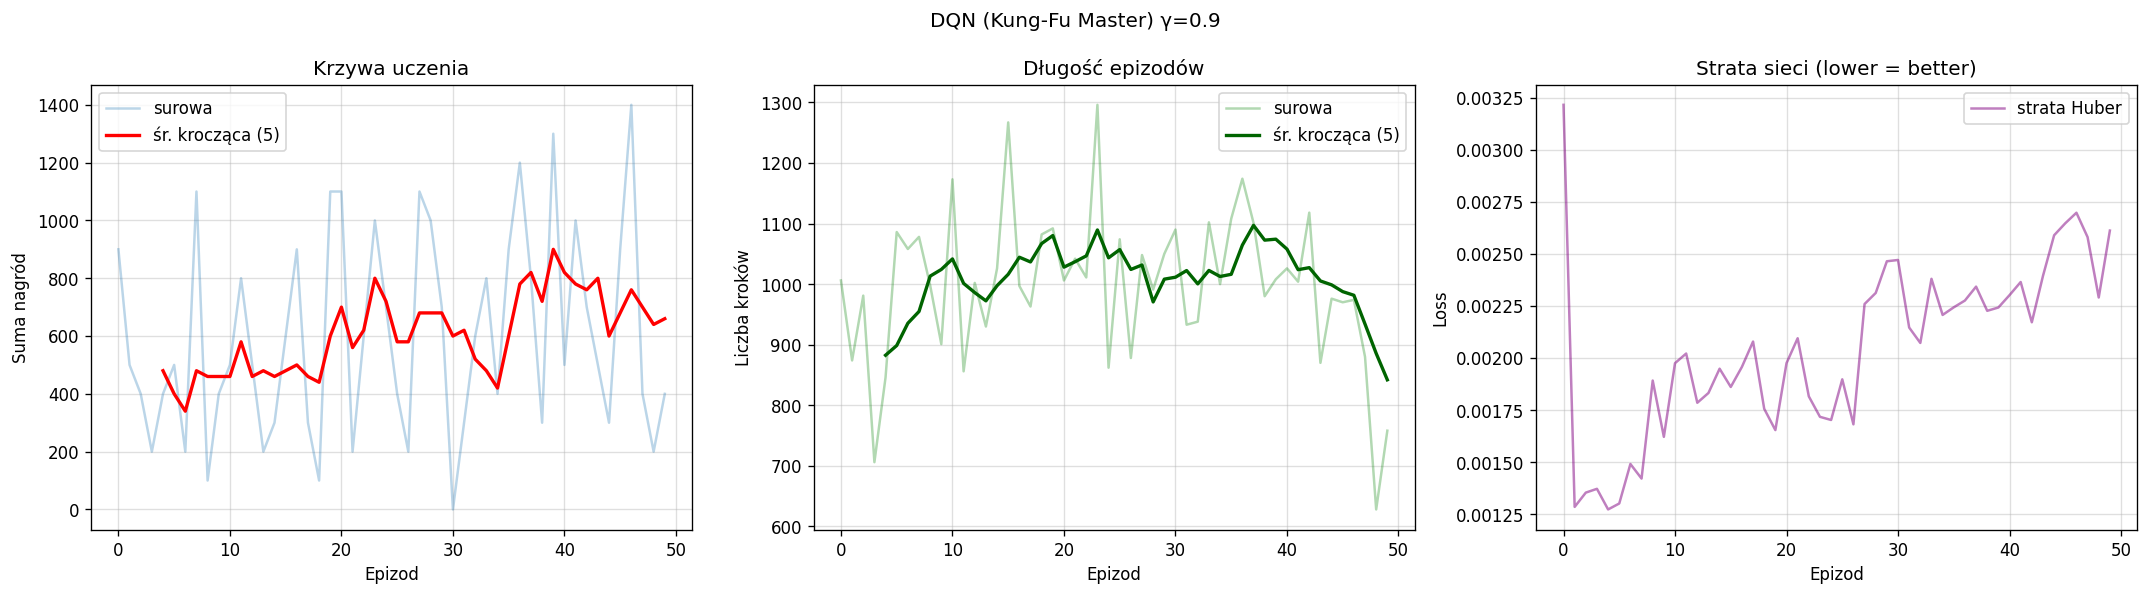

In [12]:
from IPython.display import Image, display
display(Image('results/kungfu_qlearning/curve.png'))
display(Image('results/kungfu_dqn/curve.png'))

### Uczenie ze wzmocnieniem - eksperymenty

**Zmiana przestrzeni stanów** Próbowaliśmy najpierw użyć całego RAM-u (128 bajtów) zbinowanych na 8 koszyków. Skutek: agent po 1000 epizodów odwiedził dziesiątki tysięcy unikatowych stanów, a w żadnym z nich nie zdążył nauczyć się sensownej polityki - krzywa uczenia była płaska lub zmniejszała się znacznie średnia wyników podczas uczenia. Redukcja do 8 wybranych bajtów × 4 koszyki umozliwiło faktyczne uczenie.

**Ograniczenie parametrów DQN** Pierwotnie sieć zwracała Q-wartości rzędu setek tysięcy (efekt dywergencji), agent wybierał akcje deterministycznie powtarzając tę samą (najczęściej `NOOP` lub `FIRE`), a średnia nagroda systematycznie spadała. Po wprowadzeniu target network, klipowania nagród, Hubera i clip_grad_norm - wartości Q mieszczą się w sensownym zakresie (3-10), a krzywa uczenia szła w górę.

**Wnioski:**
- Q-Learning radzi sobie zaskakująco dobrze, gdy ilość stanów jest sensownie zredukowana. Bez redukcji - nie uczy się nic.
- DQN potrzebuje wielu poprawek stabilizujących, by faktycznie wykorzystać swoją moc, naiwna, prosta implementacja może wręcz pogarszać wyniki.
- W krótkim treningu (50 ep) DQN nie wyprzedza Q-Learningu, a uczenie sieci zajmuje duzo więcej czasu - opłaca się prostrzy algorytm.

## Problem ciągły: Lunar Lander

**Środowisko:** `LunarLander-v3` z `continuous=True`.

Agent steruje ciągłym środowiskiem sterowania lądownikiem księżycowym. Obserwacja jest 8-wymiarowym wektorem z ciągłymi wartościami. Akcje: w wersji ciągłej dwa silniki (siła i kierunek). Nagroda: bonus za wylądowanie między flagami (+100), kara za rozbicie (-100), niewielka kara za zużyte paliwo. Środowisko uznaje się za rozwiązane przy średniej > 200.

Zaimplementowaliśmy dwa algorytmy dla tego problemu:

1. **PPO (Proximal Policy Optimization)** - na wersji `continuous=True`. PPO jest algorytmem aktor-krytyk z "clipped surrogate objective" - aktualizacje polityki są ograniczone, by nie zmieniała się drastycznie.
2. **DQN (Deep Q-Network)** - na wersji `continuous=False` (bo DQN wymaga dyskretnych akcji). Obserwacje pozostają ciągłe.

Oba modele trenowano przez 80 000 kroków środowiska z γ=0.9.

,Algorytm,Epizody,lr,γ,Najlepsza,Średnia,Pierwsze 25%,Ostatnie 25%,Poprawa,Sukcesy(>200)
0,PPO,188,0.00030,0.9,84.5,-146.7,-222.9,-110.1,112.8,0/188
1,DQN (SB3),146,0.00063,0.9,3.3,-123.9,-168.0,-114.9,53.1,0/146


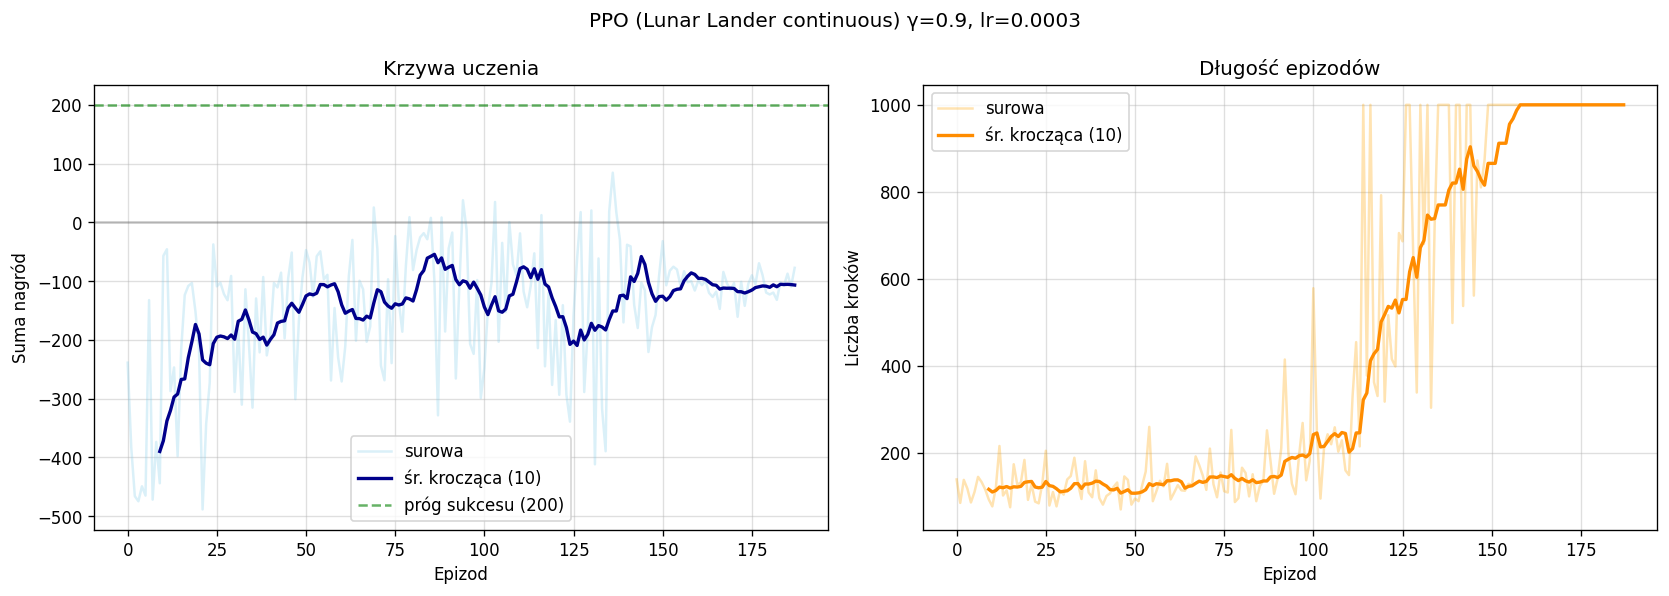

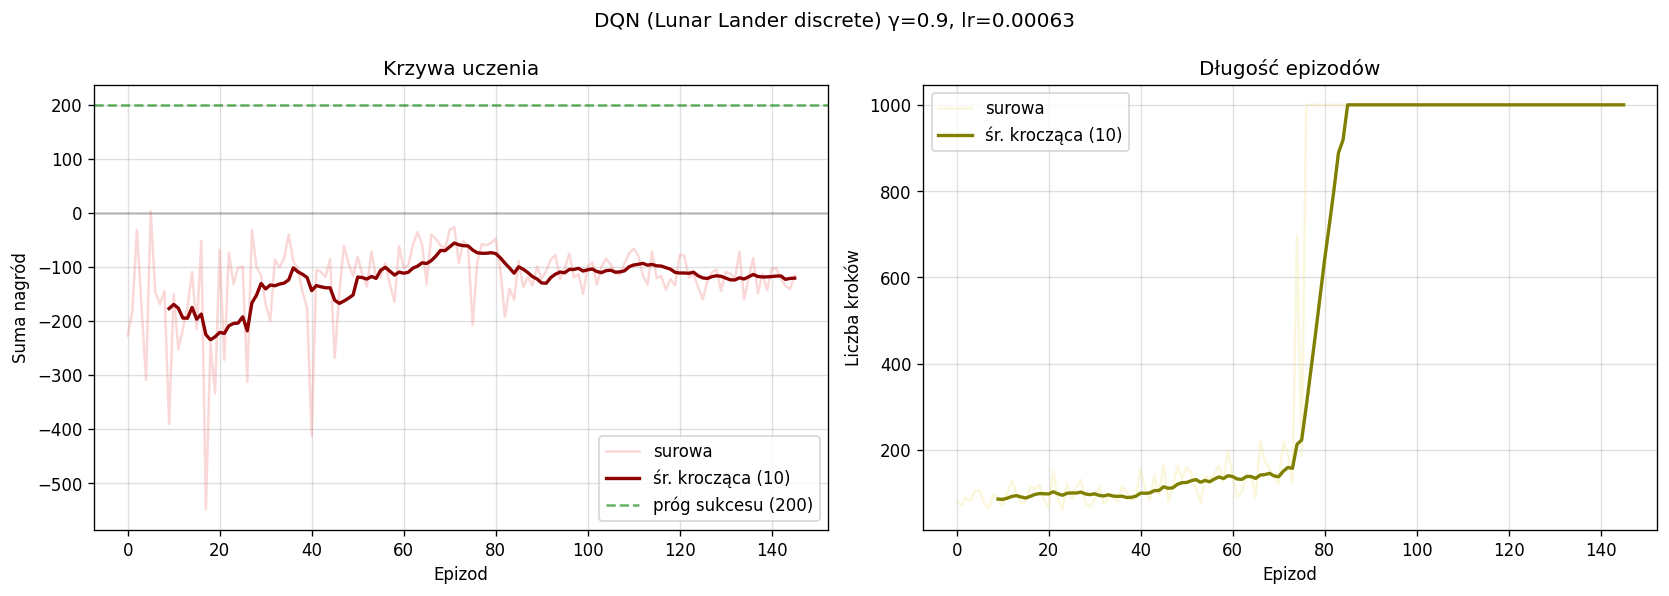

In [13]:
import json, os
import pandas as pd
from IPython.display import Image, display

with open('results/lunar_ppo/summary.json') as f:
    s_ppo = json.load(f)
with open('results/lunar_dqn/summary.json') as f:
    s_dqnL = json.load(f)

df_ll = pd.DataFrame([
    {'Algorytm': s_ppo['algorithm'], 'Epizody': s_ppo['n_episodes'],
     'lr': s_ppo['learning_rate'], 'γ': s_ppo['gamma'],
     'Najlepsza': round(s_ppo['best_reward'],1),
     'Średnia': round(s_ppo['mean_reward'],1),
     'Pierwsze 25%': round(s_ppo['mean_first_25%'],1),
     'Ostatnie 25%': round(s_ppo['mean_last_25%'],1),
     'Poprawa': round(s_ppo['improvement'],1),
     'Sukcesy(>200)': f"{s_ppo['solved_episodes']}/{s_ppo['n_episodes']}"},
    {'Algorytm': s_dqnL['algorithm'], 'Epizody': s_dqnL['n_episodes'],
     'lr': s_dqnL['learning_rate'], 'γ': s_dqnL['gamma'],
     'Najlepsza': round(s_dqnL['best_reward'],1),
     'Średnia': round(s_dqnL['mean_reward'],1),
     'Pierwsze 25%': round(s_dqnL['mean_first_25%'],1),
     'Ostatnie 25%': round(s_dqnL['mean_last_25%'],1),
     'Poprawa': round(s_dqnL['improvement'],1),
     'Sukcesy(>200)': f"{s_dqnL['solved_episodes']}/{s_dqnL['n_episodes']}"},
])
display(df_ll)
display(Image('results/lunar_ppo/curve.png'))
display(Image('results/lunar_dqn/curve.png'))

### Wyniki (80k kroków)

Oba algorytmy widocznie się uczą: PPO poprawia średnią z -223 do -110, DQN z -168 do -115. Najlepszy epizod PPO daje +85 pkt, DQN tylko +3 - PPO ma większą wariancję dobrych wyników. Żaden algorytm nie osiągnął jeszcze progu 200 (rozwiązania zadania), ale:

- 80 000 kroków to za mało -  dla pełnego rozwiązania Lunar Landera .
- widać, że oba algorytmy się uczą poprawnie - krzywe rosną stabilnie.
- **DQN** uczy się trochę lepszej gorzej, ale za to stabilnie.
- **PPO** znacznie bardziej eksploruje - dlatego trafia na pojedyncze udane lądowania, ale ma nizszy dolny próg i krzywa uczenia bardziej oscyluje.

### Zmiana współczynników dyskontowych

,γ,Epizody,Średnia,Średnia ostatnie 25%,Najlepsza,Zdyskontowana suma (1000 ep.)
0,0.50,180,-261.0,-265.6,13.6,-268.2
1,0.90,150,-156.1,-58.2,101.6,-2249.0
2,0.99,179,-148.3,-85.7,76.0,-14948.3


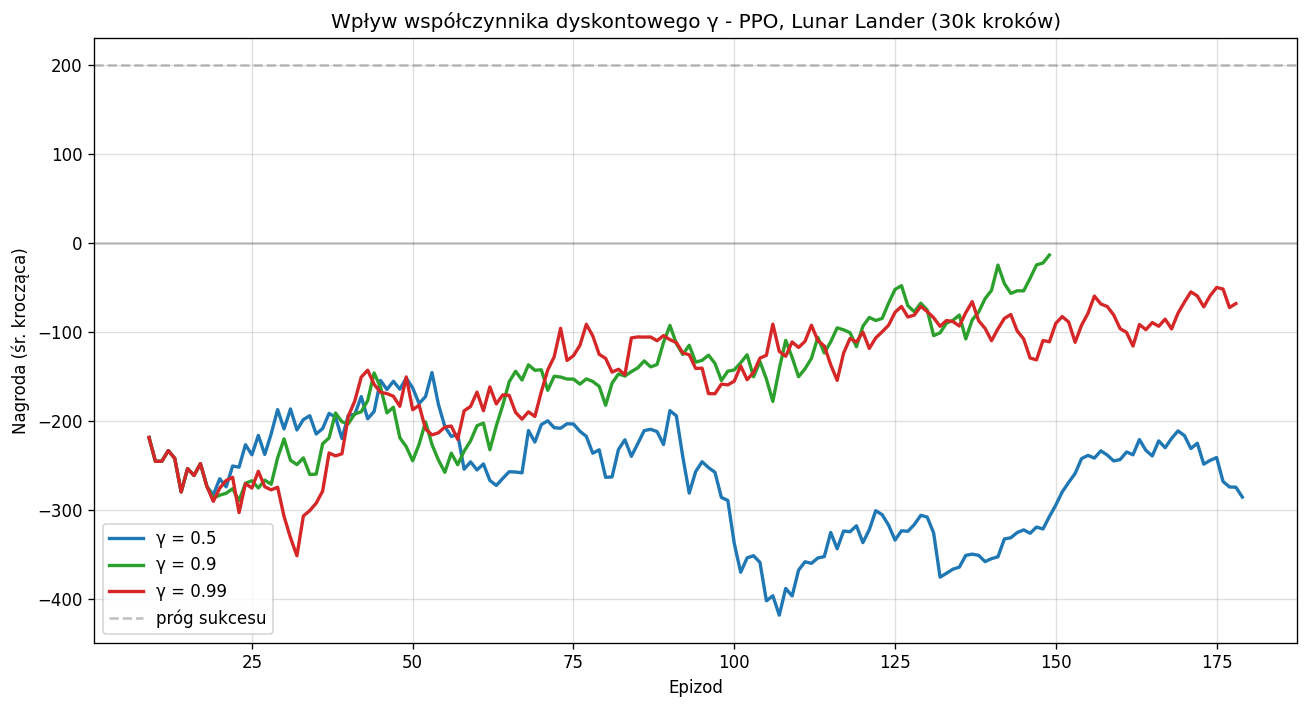

In [14]:
import json
import pandas as pd
from IPython.display import Image, display

with open('results/lunar_experiments/gamma_comparison.json') as f:
    g = json.load(f)

df_g = pd.DataFrame([
    {'γ': float(k),
     'Epizody': v['n_episodes'],
     'Średnia': round(v['mean'], 1),
     'Średnia ostatnie 25%': round(v['mean_last_25%'], 1),
     'Najlepsza': round(v['best'], 1),
     'Zdyskontowana suma (1000 ep.)': round(v['discounted_first_1000'], 1)}
    for k, v in g.items()
]).sort_values('γ')
display(df_g)
display(Image('results/lunar_experiments/gamma_comparison.png'))

**Analiza wpływu γ (PPO, Lunar Lander, 30 000 kroków każda wersja)**

| γ | Charakterystyka agenta | Średnia (ostatnie 25%) |
|---|---|---|
| **0.5** | Bardzo "krótkowzroczny" - liczy się tylko nagroda za 1-2 kroki naprzód. Lądowanie wymaga długiej sekwencji manewrów, więc agent nigdy nie planuje całego lądowania. | -266 |
| **0.9** | Złoty środek - agent docenia odległe nagrody, ale uczenie pozostaje stabilne. Osiąga najlepsze wyniki na końcu treningu. | **-58** |
| **0.99** | Bardzo dalekowzroczny - teoretycznie najlepszy dla problemów o długiej drodze do rozwiązania. Rośnie wolniej niz γ=0.9. |  -86 |

**Wnioski:** dla problemu Lunar Lander γ=0.9 najbardziej odpowiednim z rozwazanych współczynników w naszym budżecie obliczeniowym. γ=0.99 przy dłuższym treningu prawdopodobnie wyprzedziłaby γ=0.9 
, ale wymaga znacznie dłuzszego procesu uczenia do stabilizacji.

## Porównanie algorytmów

Optymalizacja hiperparametrów - grid search 2 lr × 2 γ na PPO Lunar Landerze. Kryterium oceny: całkowita zdyskontowana nagroda w pierwszych 1000 epizodach.

,lr,γ,epizody,średnia,ostatnie 25%,zdysk. nagroda (1000 ep.)
0,0.0,0.9,150,-192.9,-164.9,-2197.5
1,0.0,0.9,130,-174.3,-113.5,-2249.0
2,0.0,1.0,140,-165.8,-98.7,-14258.8
3,0.0,1.0,157,-176.0,-103.8,-15878.0


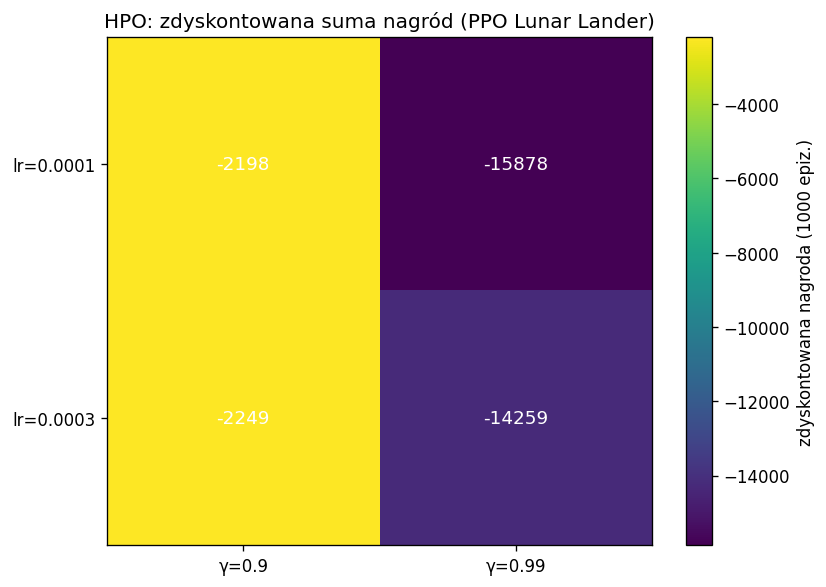

In [15]:
import json
import pandas as pd
from IPython.display import Image, display

with open('results/lunar_experiments/hpo_results.json') as f:
    hpo = json.load(f)

df_h = pd.DataFrame(hpo).sort_values('discounted_first_1000', ascending=False)
df_h = df_h.rename(columns={
    'learning_rate': 'lr', 'gamma': 'γ', 'n_episodes': 'epizody',
    'mean_reward': 'średnia',
    'mean_last_25%': 'ostatnie 25%',
    'discounted_first_1000': 'zdysk. nagroda (1000 ep.)'
})
display(df_h.round(1).reset_index(drop=True))
display(Image('results/lunar_experiments/hpo_heatmap.png'))

### Wyniki optymalizacji hiperparametrów (PPO Lunar Lander, 20 000 kroków na konfigurację):

Najwyższą zdyskontowaną sumę nagród w pierwszych 1000 epizodach uzyskała konfiguracja lr=1e-4, γ=0.9 (-2197). Druga w kolejności - lr=3e-4, γ=0.9 (-2249) - jest jednak lepsza pod względem średniej z ostatnich 25% epizodów (-114 vs -165).

Wnioski: kryterium "zdyskontowana suma w 1000 epizodach" faworyzuje wolniejsze uczenie z mniejszym lr, bo na początku oba modele są tak samo słabe, ale wyższy lr daje większą wariancję wczesnych nagród (czasem bardzo złe). Dla finalnej jakości polityki lepszym kryterium jest średnia z końcówki treningu - tam wygrywa lr=3e-4.
